## Fitting hMFC to a simulated dataset

In [80]:
from jax import vmap
import jax.numpy as jnp
import jax.random as jr
from jax.nn import sigmoid
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from fastprogress import progress_bar
from scipy.stats import spearmanr
from matplotlib.backends.backend_pdf import PdfPages
from tensorflow_probability.substrates import jax as tfp

tfd = tfp.distributions

from hmfc.model import HierarchicalBernoulliLDS
from hmfc.gibbs import gibbs_step


In [81]:
sns.set_theme(style="ticks", context="paper",
        rc={"axes.titlesize": 16,
            "axes.labelsize": 14,
            "xtick.labelsize": 12,
            "ytick.labelsize": 12,
            "axes.spines.right": False,
            "axes.spines.top": False
            })

### Initialize some variables

In [82]:

""" Specify some variables and the true value for the hierarchical (global/group) parameters
   
    num_iters: number of iterations for the estimation procedure
    num_inputs: number of input variables
    num_subjects: number of subjects
    num_trials: number of trials per subject
   
    true_mu: true mean of truncated normal for AR coefficient
    true_sigma_a: true standard deviation of truncated normal for AR coefficient
    true_mu_w: true means of normal distributions for input variables
    true_sigma_w: true standard deviations of normal distributions for input variables
    true_mu_sigmasq: true mu of inverse gamma (used to estimate alpha) for sigma_sq
    true_beta_sigmasq: true beta of inverse gamma for sigma_sq
    true_sigma_mu_x: true standard deviation of normal distribution for mu_x
"""

num_subjects = 50
num_trials = 500
num_iters = 1000 # number of iterations per chain 
num_chains = 4 # number of chains for the MCMC sampling
num_inputs = 3
burn_in = 250 # number of iterations to burn per chain

true_mu_a = 0.98
true_sigma_a = 0.03
true_mu_w = jnp.array([0.0, 0.2, -0.1])
true_sigma_w = jnp.array([1.0, 1.0, 1.0])
true_mu_sigmasq = 0.2
true_beta_sigmasq = 0.5
true_sigma_mu_x = 0.5

# Create our true model
true_model = HierarchicalBernoulliLDS(num_inputs,
                                      mu_a=true_mu_a, 
                                      sigma_a=true_sigma_a, 
                                      mu_w=true_mu_w, 
                                      sigma_w=true_sigma_w, 
                                      mu_sigmasq=true_mu_sigmasq,
                                      beta_sigmasq=true_beta_sigmasq, 
                                      sigma_mu_x=true_sigma_mu_x)


In [83]:
# Sample inputs
k1, k2 = jr.split(jr.PRNGKey(0))
inputs = tfd.Normal(0, 1.0).sample(sample_shape=(num_subjects, num_trials, num_inputs), seed=k1)

# HMFC REQUIRESTHAT INPUTS ARE MEAN ZERO
inputs -= inputs.mean(axis=0)

# Sample true params, states, and emissions
true_params, true_states, emissions = true_model.sample(k2, inputs)

# Create masking variable: helps the model to deal with varying numbers of trials per subject
masks = jnp.ones_like(emissions)


### Fit model

In [84]:
def initialize_and_fit_model(key):
    
    """
    Initialize model
    """
    key = jr.PRNGKey(key) if isinstance(key, int) else key
    k1, k2, k3, k4, k5, k6, k7 = jr.split(key, 7)
     
    init_mu_w = tfd.Uniform(-1.0, 1.0).sample(seed=k1, sample_shape=(num_inputs,))
    init_sigma_w = tfd.Uniform(0.1, 1.0).sample(seed=k2, sample_shape=(num_inputs,))
    init_mu_a = tfd.Uniform(0.5, 0.995).sample(seed=k3)
    init_sigma_a = tfd.Uniform(0.1, 0.2).sample(seed=k4) # there is an upper limit for sigma_a, so don't exceed 0.2, otherwise parameter is not updated!
    init_mu_sigmasq = tfd.Uniform(0.05, 0.2).sample(seed=k5)
    init_beta_sigmasq = tfd.Uniform(0.05, 0.5).sample(seed=k6)
    init_sigma_mu_x = tfd.Uniform(0.1, 0.5).sample(seed=k7)
    
    model = HierarchicalBernoulliLDS(num_inputs, init_mu_a, init_sigma_a, init_mu_w, init_sigma_w, init_mu_sigmasq, init_beta_sigmasq, init_sigma_mu_x)
    params, states, _ = model.sample(key, inputs) # sample initial per-subject parameters and states (criterion trajectory)


    """
    Fit model
    """
    lps = jnp.zeros((num_iters,)) # log probability
    
    posterior_samples_mu_a = jnp.zeros((num_iters,))
    posterior_samples_sigma_a = jnp.zeros((num_iters,))
    posterior_samples_mu_w = jnp.zeros((num_iters, num_inputs))
    posterior_samples_sigma_w = jnp.zeros((num_iters, num_inputs))
    posterior_samples_mu_sigmasq = jnp.zeros((num_iters,))
    posterior_samples_beta_sigmasq = jnp.zeros((num_iters,))
    posterior_samples_sigma_mu_x = jnp.zeros((num_iters,))
    
    posterior_samples_a = jnp.zeros((num_iters, num_subjects))
    posterior_samples_sigmasq = jnp.zeros((num_iters, num_subjects))
    posterior_samples_w = jnp.zeros((num_iters, num_subjects, num_inputs))
    posterior_samples_mu_x = jnp.zeros((num_iters, num_subjects))

    posterior_samples_states = jnp.zeros((num_iters, num_subjects, num_trials))
    
    for itr in progress_bar(range(num_iters)):

        this_key, key = jr.split(key)
        lp, states, params, model = gibbs_step(this_key, emissions, masks, states, inputs, params, model)
        
        lps = lps.at[itr].set(lp)

        posterior_samples_mu_a = posterior_samples_mu_a.at[itr].set(sigmoid(model.logit_mu_a))
        posterior_samples_sigma_a = posterior_samples_sigma_a.at[itr].set(jnp.exp(model.log_sigma_a))
        posterior_samples_mu_w = posterior_samples_mu_w.at[itr].set(model.mu_w)
        posterior_samples_sigma_w = posterior_samples_sigma_w.at[itr].set(jnp.exp(model.log_sigma_w))
        posterior_samples_mu_sigmasq = posterior_samples_mu_sigmasq.at[itr].set(jnp.exp(model.log_mu_sigmasq))
        posterior_samples_beta_sigmasq = posterior_samples_beta_sigmasq.at[itr].set(jnp.exp(model.log_beta_sigmasq))
        posterior_samples_sigma_mu_x = posterior_samples_sigma_mu_x.at[itr].set(jnp.exp(model.log_sigma_mu_x))


        posterior_samples_a = posterior_samples_a.at[itr].set(params['a'])
        posterior_samples_sigmasq = posterior_samples_sigmasq.at[itr].set(params['sigmasq'])
        posterior_samples_w = posterior_samples_w.at[itr].set(params['w'])
        posterior_samples_mu_x = posterior_samples_mu_x.at[itr].set(params['mu_x'])
        
        posterior_samples_states = posterior_samples_states.at[itr].set(states)
    

    return posterior_samples_mu_a, posterior_samples_sigma_a, posterior_samples_mu_w, posterior_samples_sigma_w, posterior_samples_mu_sigmasq, posterior_samples_beta_sigmasq, posterior_samples_sigma_mu_x, posterior_samples_a, posterior_samples_sigmasq, posterior_samples_w, posterior_samples_mu_x, posterior_samples_states, lps



### Run multiple chains in parallel

In [85]:
keys = jr.split(jr.PRNGKey(0), num_chains)

posterior_samples_mu_a, posterior_samples_sigma_a, posterior_samples_mu_w, posterior_samples_sigma_w, posterior_samples_mu_sigmasq, posterior_samples_beta_sigmasq, posterior_samples_sigma_mu_x, posterior_samples_a, posterior_samples_sigmasq, posterior_samples_w, posterior_samples_mu_x, posterior_samples_states, lps = vmap(initialize_and_fit_model)(keys)


### Log joint probability

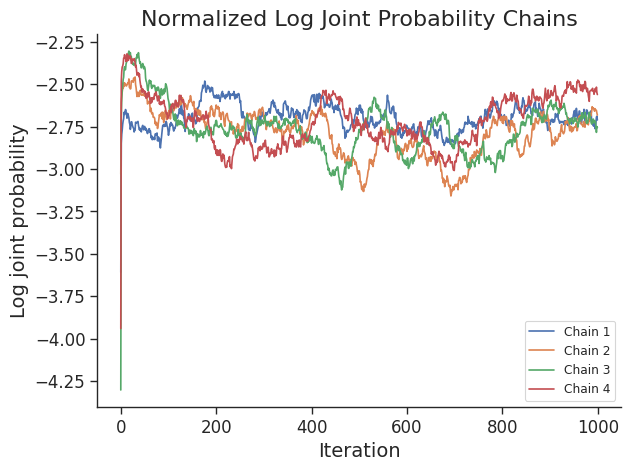

In [86]:
""" 
Check log joint probability to assess convergence and determine number of burn-in iterations

Ideally, the log joint probability should stabilize and fluctuate around a certain value for a couple of hundereds iterations.
If it is still clearly increasing then rerun the model with more iterations. The first iterations where the log joint probability
is still increasing should be considered burn-in.
"""

for i in range(lps.shape[0]):
    plt.plot(lps[i]/emissions.size, label=f'Chain {i + 1}') 

plt.xlabel("Iteration")
plt.ylabel("Log joint probability")
plt.title("Normalized Log Joint Probability Chains") 
plt.legend() 
plt.tight_layout()
plt.show()

### Estimated criterion fluctuations

In [87]:
post_states = posterior_samples_states[:,burn_in:,:,:] # (num_chains, num_iterations, num_subjects, num_trials)
post_states = post_states.reshape(-1, num_subjects, num_trials) # collapse samples over the chains

posterior_samples_states_mean = jnp.mean(post_states[:,:,:], axis=0) 
posterior_samples_states_std = jnp.std(post_states[:,:,:], axis=0)

with PdfPages(f'{num_subjects}subjects_{num_trials}trials_estimated_states.pdf') as pdf:
  for subject in range(num_subjects):
      
      plt.figure(figsize=(8, 6))
      plt.plot(true_states[subject], label="True states")
      plt.plot(posterior_samples_states_mean[subject], label="Inferred states")
      plt.fill_between(jnp.arange(num_trials), #95% CI
                  posterior_samples_states_mean[subject] - 2 * posterior_samples_states_std[subject],
                  posterior_samples_states_mean[subject] + 2 * posterior_samples_states_std[subject], color='r', alpha=0.25)
      plt.xlabel("Trial")
      plt.ylabel("Criterion $x_t$")
      plt.title(r"Subject {:d}".format(subject))
      plt.legend(loc='lower right')
      r, p = spearmanr(true_states[subject], posterior_samples_states_mean[subject])
      plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.95), xycoords='axes fraction')

      pdf.savefig()
      plt.close()


#### Estimated criterion fluctuations: example subject

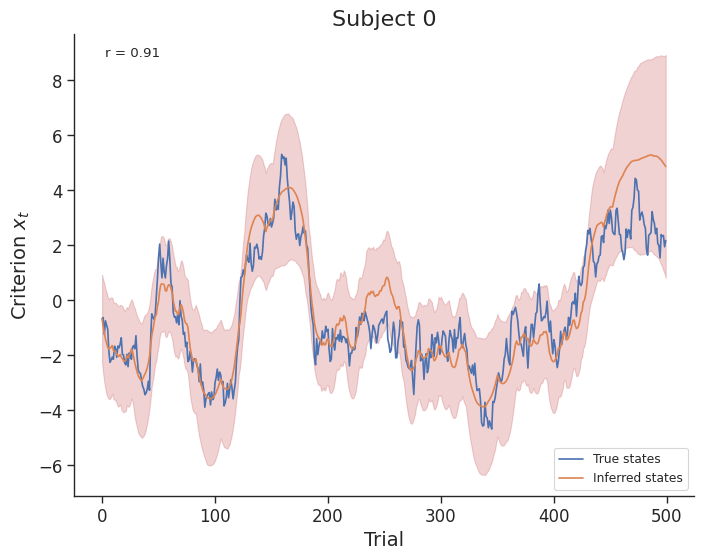

In [88]:
post_states = posterior_samples_states[:,burn_in:,:,:] # (num_chains, num_iterations, num_subjects, num_trials)
post_states = post_states.reshape(-1, num_subjects, num_trials) # collapse samples over the chains

posterior_samples_states_mean = jnp.mean(post_states[:,:,:], axis=0) 
posterior_samples_states_std = jnp.std(post_states[:,:,:], axis=0)

subject = 0

plt.figure(figsize=(8, 6))
plt.plot(true_states[subject], label="True states")
plt.plot(posterior_samples_states_mean[subject], label="Inferred states")
plt.fill_between(jnp.arange(num_trials), #95% CI
          posterior_samples_states_mean[subject] - 2 * posterior_samples_states_std[subject],
          posterior_samples_states_mean[subject] + 2 * posterior_samples_states_std[subject], color='r', alpha=0.25)
plt.xlabel("Trial")
plt.ylabel("Criterion $x_t$")
plt.title(r"Subject {:d}".format(subject))
plt.legend(loc='lower right')
r, p = spearmanr(true_states[subject], posterior_samples_states_mean[subject])
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.95), xycoords='axes fraction')
plt.show()


### Recovery criterion fluctuations 

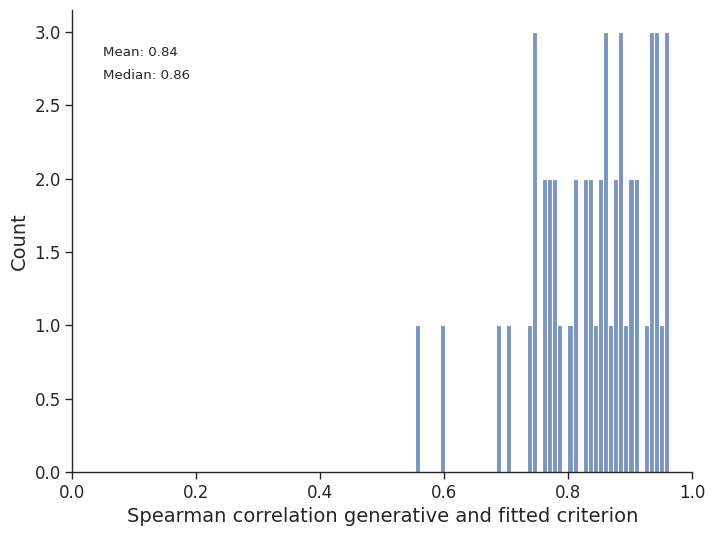

In [89]:
correlations_inferred_and_fitted_states = jnp.array([spearmanr(true_states[subject], posterior_samples_states_mean[subject])[0] for subject in range(num_subjects)])

mean_value = jnp.mean(correlations_inferred_and_fitted_states)
median_value = jnp.median(correlations_inferred_and_fitted_states)

plt.figure(figsize=(8, 6))
sns.histplot(correlations_inferred_and_fitted_states, bins=50)
plt.annotate(f'Mean: {mean_value:.2f}', xy=(0.05, 0.90), xycoords='axes fraction')
plt.annotate(f'Median: {median_value:.2f}', xy=(0.05, 0.85), xycoords='axes fraction')
plt.xlabel('Spearman correlation generative and fitted criterion')
plt.ylabel('Count')
plt.xlim(0, 1)
plt.show()

### Per-subject parameters

####  Compare true and inferred estimates of $a_i$

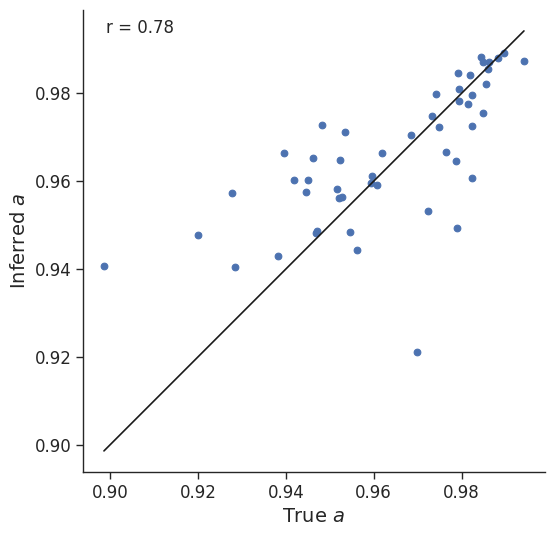

In [90]:
post_a = posterior_samples_a[:,burn_in:,:] # (num_chains, num_iterations, num_subjects)
post_a = post_a.reshape(-1, num_subjects) # collapse samples over the chains

posterior_mean_a = jnp.mean(post_a[burn_in:], axis=0)

a_min = min(true_params['a'].min(), posterior_mean_a.min())
a_max = max(true_params['a'].max(), posterior_mean_a.max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params['a'], posterior_mean_a)
plt.plot([a_min, a_max], [a_min, a_max], '-k')
plt.xlabel("True $a$")
plt.ylabel("Inferred $a$")
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params['a'], posterior_mean_a)
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)
plt.show()

#### Compare true and inferred estimates of $\sigma^2_i$

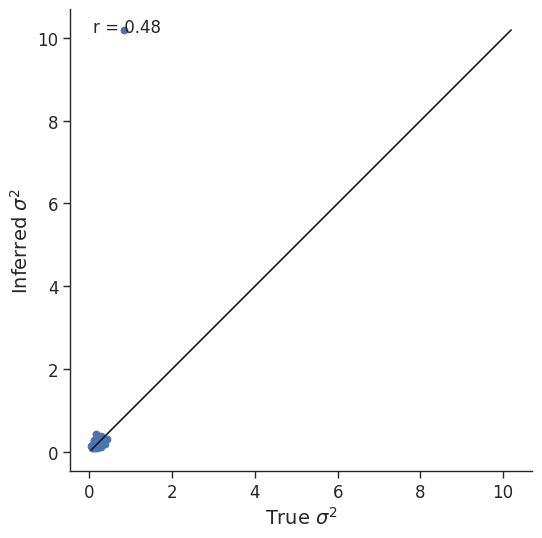

In [91]:
post_sigmasq = posterior_samples_sigmasq[:,burn_in:,:] # (num_chains, num_iterations, num_subjects)
post_sigmasq = post_sigmasq.reshape(-1, num_subjects) # collapse samples over the chains

posterior_mean_sigmasq = jnp.mean(post_sigmasq[burn_in:], axis=0)
  
sigmasq_min = min(true_params['sigmasq'].min(), posterior_mean_sigmasq.min())
sigmasq_max = max(true_params['sigmasq'].max(), posterior_mean_sigmasq.max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params['sigmasq'], posterior_mean_sigmasq)
plt.plot([sigmasq_min, sigmasq_max], [sigmasq_min, sigmasq_max], '-k')
plt.xlabel("True $\sigma^2$")
plt.ylabel("Inferred $\sigma^2$")
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params['sigmasq'], posterior_mean_sigmasq)
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)
plt.show()

#### Compare true and inferred estimates of $\mu_{x,i}$

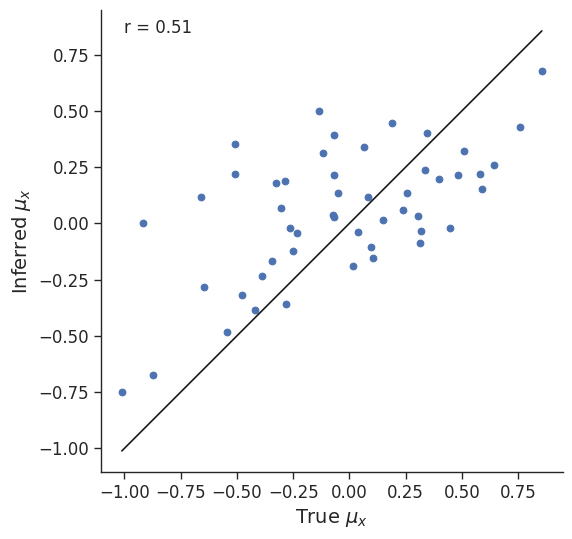

In [92]:
post_mu_x = posterior_samples_mu_x[:,burn_in:,:] # (num_chains, num_iterations, num_subjects)
post_mu_x = post_mu_x.reshape(-1, num_subjects) # collapse samples over the chains

posterior_mean_mu_x = jnp.mean(post_mu_x[burn_in:], axis=0)

mu_x_min = min(true_params['mu_x'].min(), posterior_mean_mu_x.min())
mu_x_max = max(true_params['mu_x'].max(), posterior_mean_mu_x.max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params['mu_x'], posterior_mean_mu_x)
plt.plot([mu_x_min, mu_x_max], [mu_x_min, mu_x_max], '-k')
plt.xlabel("True $\mu_x$")
plt.ylabel("Inferred $\mu_x$")
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params['mu_x'], posterior_mean_mu_x)
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)
plt.show()

#### Compare true and inferred estimates of $w_i$

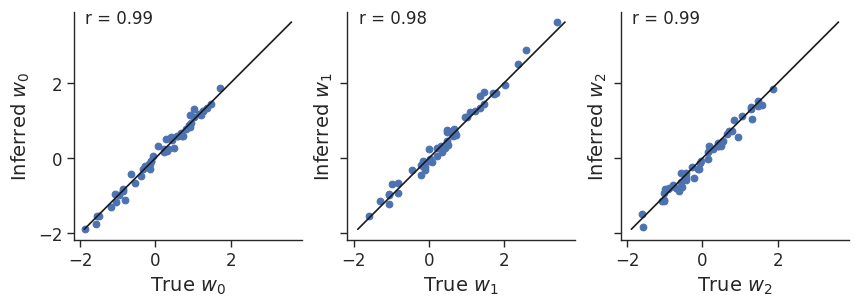

In [93]:
post_w = posterior_samples_w[:,burn_in:,:,:] # (num_chains, num_iterations, num_subjects, num_inputs)
post_w = post_w.reshape(-1, num_subjects, num_inputs) # collapse samples over the chains

w_min = min(true_params["w"].min(), jnp.mean(post_w[:,:,:], axis=0).min())
w_max = max(true_params["w"].max(), jnp.mean(post_w[:,:,:], axis=0).max())

fig, axs = plt.subplots(1, num_inputs, sharey=True, figsize=(10, 5))

for d, ax in enumerate(axs):
    ax.scatter(true_params["w"][:, d], jnp.mean(post_w[:,:,d], axis=0))
    ax.set_xlabel(r"True $w_{:d}$".format(d))
    ax.set_ylabel(r"Inferred $w_{:d}$".format(d))
    ax.plot([w_min, w_max], [w_min, w_max], '-k')
    ax.set_aspect(1.0)
    r, p = spearmanr(true_params["w"][:, d], jnp.mean(post_w[:,:,d], axis=0))
    ax.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)


### Group-level parameters

In [94]:
# Rhat should be close to 1 for all parameters
# A value of 1.1 or less is generally considered acceptable

def calculate_r_hat(samples):
    # Assuming samples is a 2D array of shape (num_chains, num_samples)
    num_chains, num_samples = samples.shape
    
    # Calculate the within-chain variance
    W = np.mean(np.var(samples, axis=1, ddof=1))
    # Calculate the between-chain variance
    chain_means = np.mean(samples, axis=1)
    B = num_samples * np.var(chain_means, ddof=1)
    # Estimate the marginal posterior variance
    var_plus = ((num_samples - 1) / num_samples) * W + (1 / num_samples) * B
    # Calculate R-hat
    r_hat = np.sqrt(var_plus / W)
    return r_hat

#### Posterior distribution of $\mu_w$

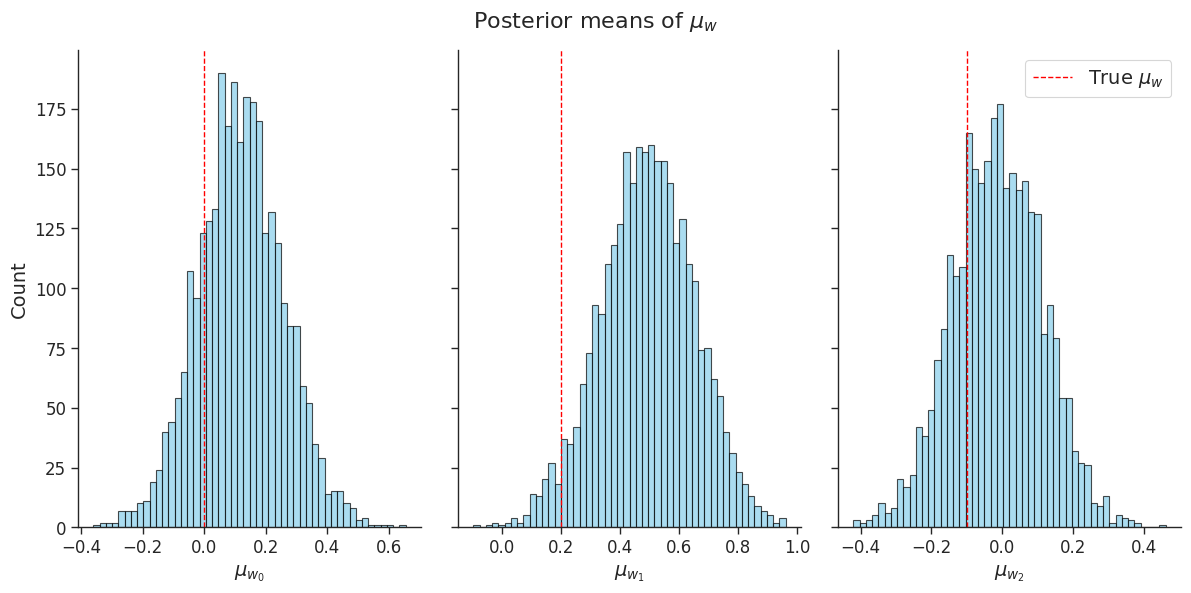

In [95]:
post_mu_w = posterior_samples_mu_w[:,burn_in:,:] # (num_chains, num_iterations, num_inputs)
post_mu_w = post_mu_w.reshape(-1, num_inputs) # collapse samples over the chains

fig, axs = plt.subplots(1, num_inputs, sharey=True, figsize=(12, 6))
for d, ax in enumerate(axs):
    ax.hist(post_mu_w[:,d], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel(r"$\mu_{{w_{:d}}}$".format(d))
    ax.axvline(true_mu_w[d], color='red', linestyle='dashed', linewidth=1, label=r'True $\mu_w$')
    if d == 0: ax.set_ylabel("Count")
plt.suptitle(r"Posterior means of $\mu_w$", fontsize=16)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

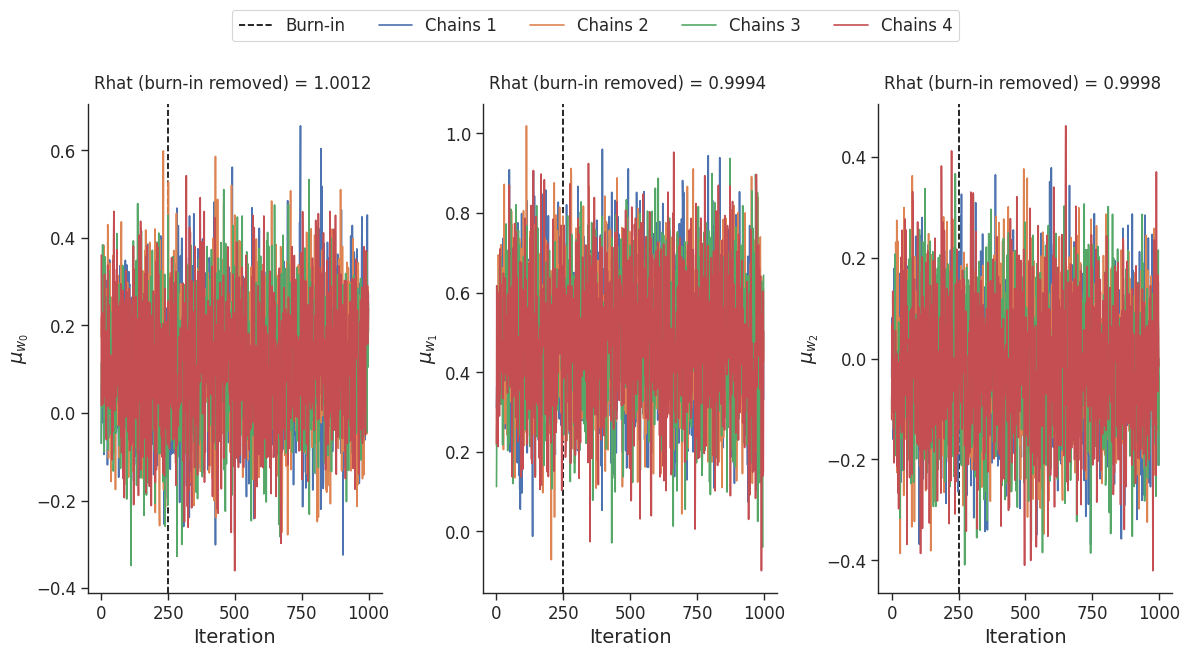

In [96]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes = axes.flatten()

for j in range(posterior_samples_mu_w.shape[2]):
    ax = axes[j]
    ax.axvline(x = burn_in, color = 'black', linestyle='dashed', label = 'Burn-in')
    
    for i in range(posterior_samples_mu_w.shape[0]):  # looping over chains
        ax.plot(posterior_samples_mu_w[i, :, j], label=f"Chains {i+1}")
    
    ax.set_xlabel("Iteration")
    ax.set_ylabel(f"$\mu_{{w_{j}}}$")
    ax.annotate(r'Rhat (burn-in removed) = {:.4f}'.format(calculate_r_hat(posterior_samples_mu_w[:, burn_in:, j])), xy=(0.02, 1.03), size= 12, xycoords='axes fraction')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.1), fontsize=12, ncol=6)
plt.tight_layout()
plt.show()


#### Posterior distribution of $\sigma_w$

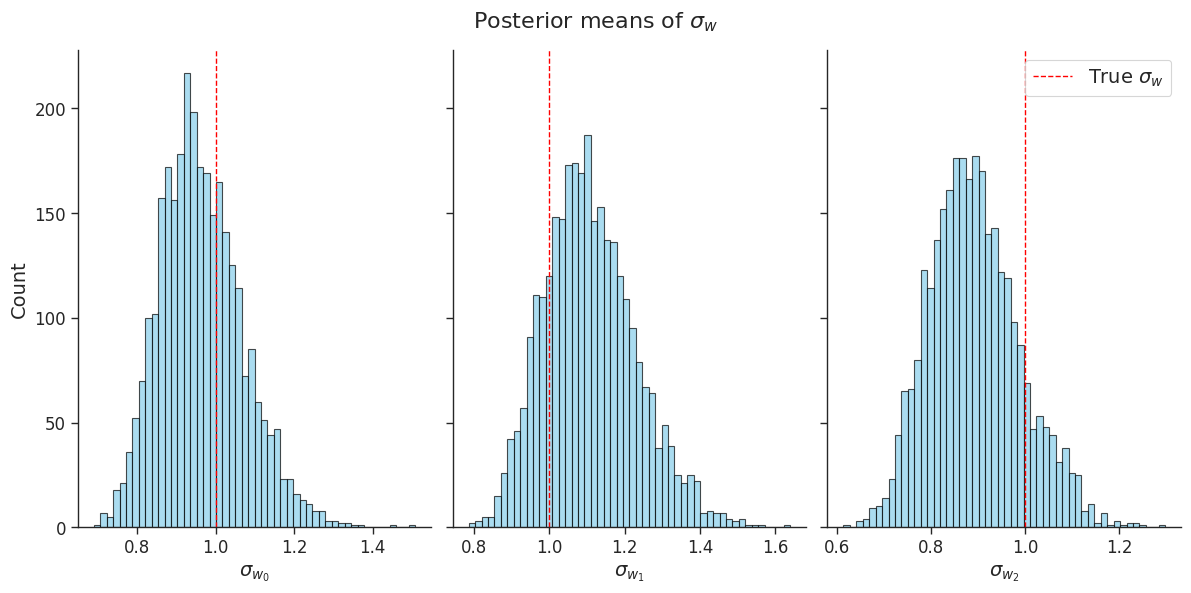

In [97]:
post_sigma_w = posterior_samples_sigma_w[:,burn_in:,:] # (num_chains, num_iterations, num_inputs)
post_sigma_w = post_sigma_w.reshape(-1, num_inputs) # collapse samples over the chains

fig, axs = plt.subplots(1, num_inputs, sharey=True, figsize=(12, 6))
for d, ax in enumerate(axs):
    ax.hist(post_sigma_w[:,d], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel(r"$\sigma_{{w_{:d}}}$".format(d))
    ax.axvline(true_sigma_w[d], color='red', linestyle='dashed', linewidth=1, label=r'True $\sigma_w$')
    if d == 0: ax.set_ylabel("Count")
plt.suptitle(r"Posterior means of $\sigma_w$", fontsize=16)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

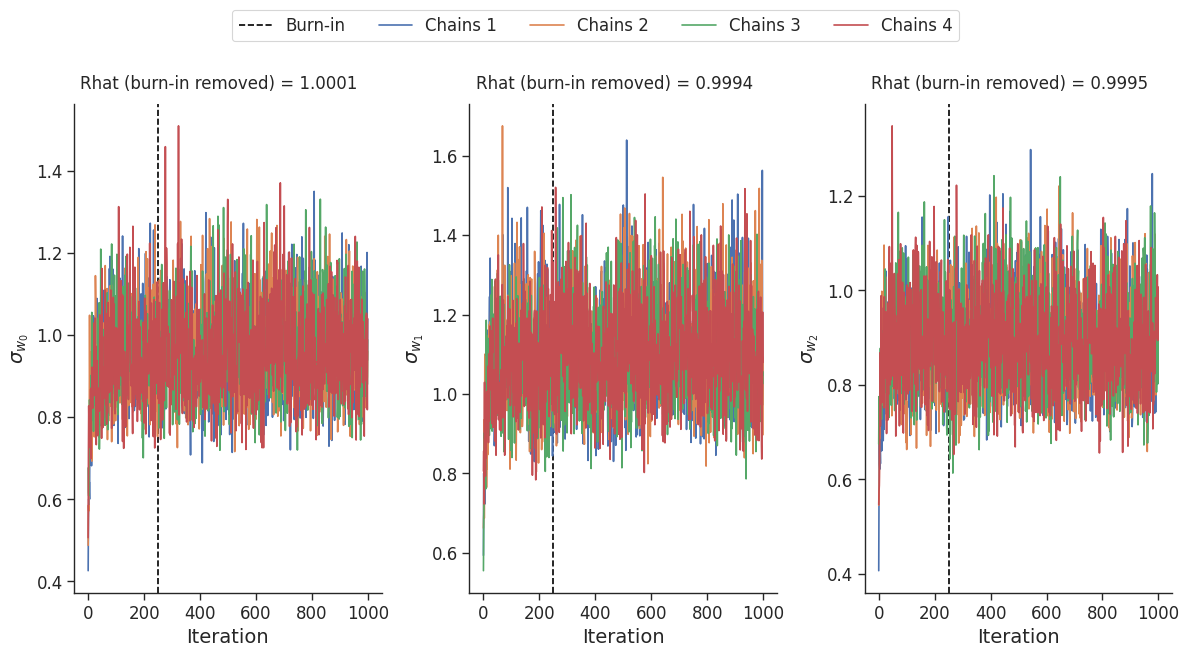

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes = axes.flatten()

for j in range(posterior_samples_sigma_w.shape[2]):
    ax = axes[j]
    ax.axvline(x = burn_in, color = 'black', linestyle='dashed', label = 'Burn-in')
    
    for i in range(posterior_samples_sigma_w.shape[0]):  # looping over chains
        ax.plot(posterior_samples_sigma_w[i, :, j], label=f"Chains {i+1}")
    
    ax.set_xlabel("Iteration")
    ax.set_ylabel(f"$\sigma_{{w_{j}}}$")
    ax.annotate(r'Rhat (burn-in removed) = {:.4f}'.format(calculate_r_hat(posterior_samples_sigma_w[:, burn_in:, j])), xy=(0.02, 1.03), size= 12, xycoords='axes fraction')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.1), fontsize=12, ncol=6)
plt.tight_layout()
plt.show()

#### Posterior distribution of $\mu_a$

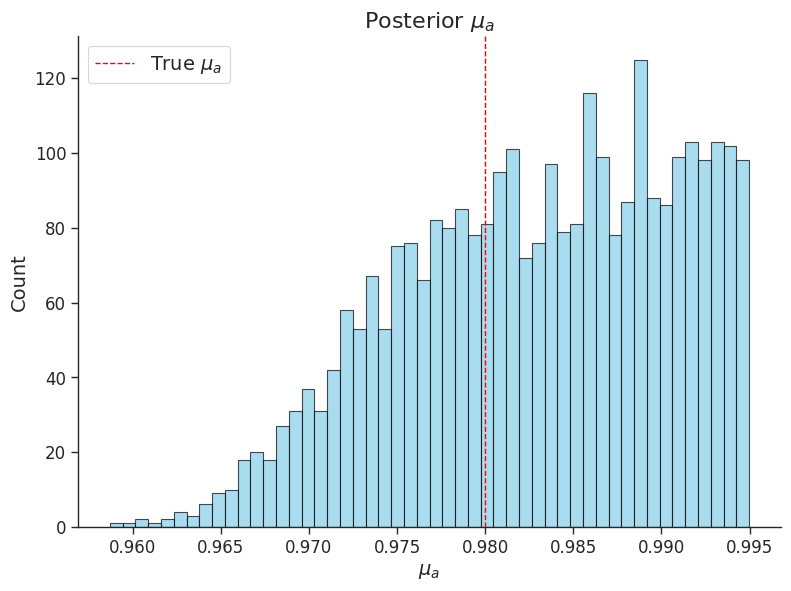

In [100]:
post_mu_a = posterior_samples_mu_a[:,burn_in:] # (num_chains, num_iterations)
post_mu_a = post_mu_a.reshape(-1) # collapse samples over the chains

plt.figure(figsize=(8, 6))
plt.hist(post_mu_a, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel(r"$\mu_a$")
plt.ylabel("Count")
plt.axvline(true_mu_a, color='red', linestyle='dashed', linewidth=1, label='True $\mu_a$')
plt.title(r"Posterior $\mu_a$")
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

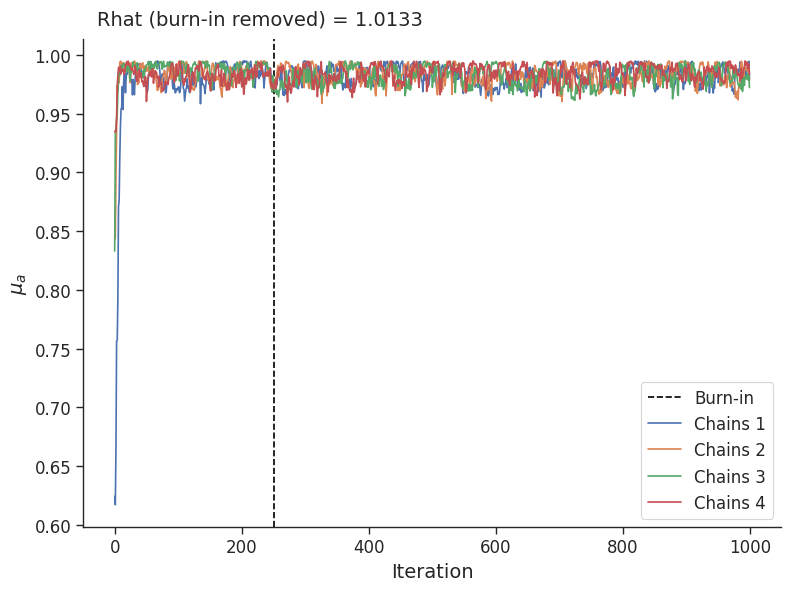

In [101]:
plt.figure(figsize=(8, 6))
plt.axvline(x = burn_in, color = 'black', linestyle='dashed', label = 'Burn-in')
for i in range(posterior_samples_mu_a.shape[0]): # looping over chains
    plt.plot(posterior_samples_mu_a[i, :], label=f"Chains {i+1}")
plt.xlabel("Iteration")
plt.ylabel(r"$\mu_{{a}}$")
plt.annotate(r'Rhat (burn-in removed) = {:.4f}'.format(calculate_r_hat(posterior_samples_mu_a[:,burn_in:])), xy=(0.02, 1.03), size= 14, xycoords='axes fraction')
plt.legend(fontsize=12) 
plt.tight_layout()
plt.show()

#### Posterior distribution of $\sigma_a$

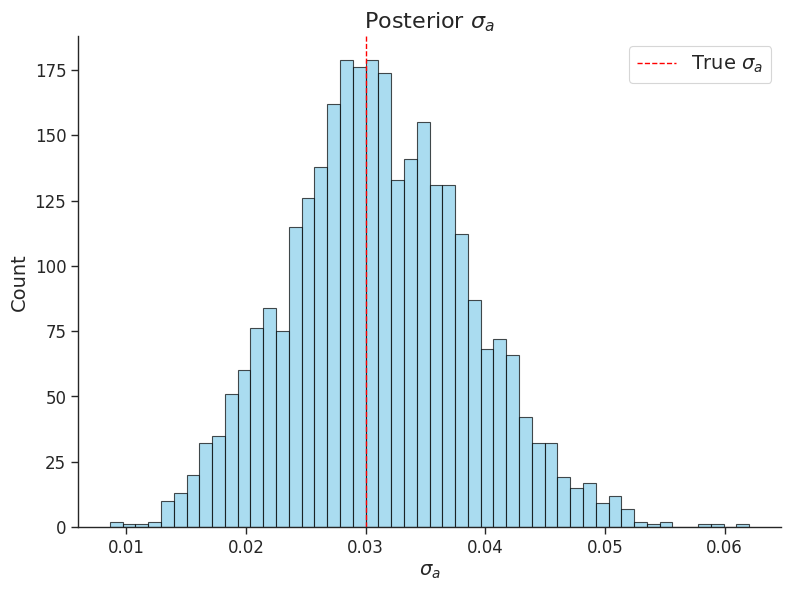

In [102]:
post_sigma_a = posterior_samples_sigma_a[:,burn_in:] # (num_chains, num_iterations)
post_sigma_a = post_sigma_a.reshape(-1) # collapse samples over the chains

plt.figure(figsize=(8, 6))
plt.hist(post_sigma_a, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel(r"$\sigma_a$")
plt.ylabel("Count")
plt.axvline(true_sigma_a, color='red', linestyle='dashed', linewidth=1, label='True $\sigma_a$')
plt.legend(fontsize=14)
plt.title(r"Posterior $\sigma_a$")
plt.tight_layout()
plt.show()  

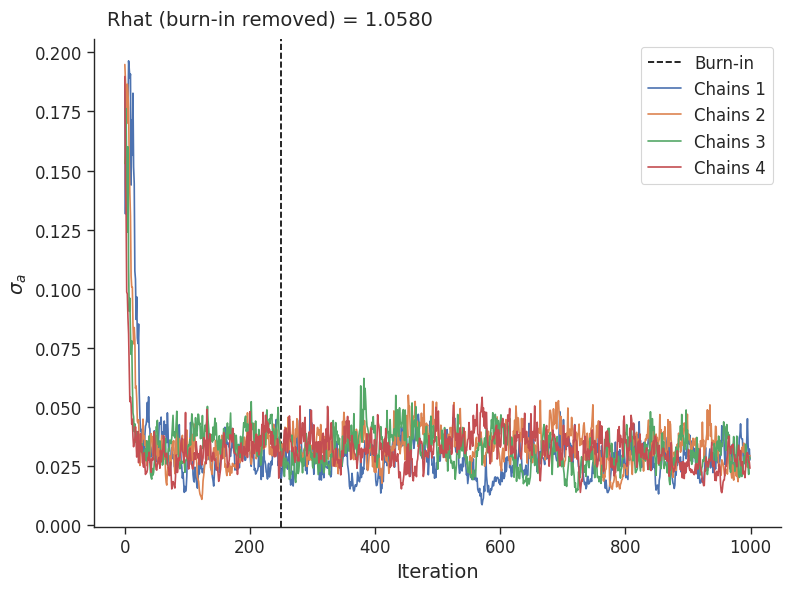

In [103]:
plt.figure(figsize=(8, 6))
plt.axvline(x = burn_in, color = 'black', linestyle='dashed', label = 'Burn-in')
for i in range(posterior_samples_sigma_a.shape[0]): # looping over chains
    plt.plot(posterior_samples_sigma_a[i, :], label=f"Chains {i+1}")
plt.xlabel("Iteration")
plt.ylabel(r"$\sigma_{{a}}$")
plt.annotate(r'Rhat (burn-in removed) = {:.4f}'.format(calculate_r_hat(posterior_samples_sigma_a[:,burn_in:])), xy=(0.02, 1.03), size= 14, xycoords='axes fraction')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

#### Posterior distribution of $\mu_{\sigma^2}$

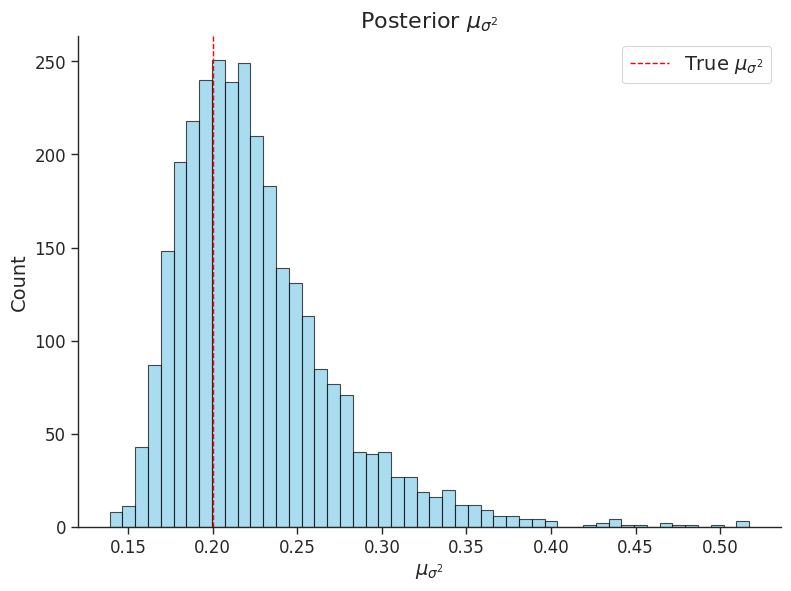

In [104]:
post_mu_sigmasq = posterior_samples_mu_sigmasq[:,burn_in:] # (num_chains, num_iterations)
post_mu_sigmasq = post_mu_sigmasq.reshape(-1) # collapse samples over the chains

plt.figure(figsize=(8, 6))
plt.hist(post_mu_sigmasq, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel(r"$\mu_{\sigma^2}$")
plt.ylabel("Count")
plt.axvline(true_mu_sigmasq, color='red', linestyle='dashed', linewidth=1, label='True $\mu_{\sigma^2}$')
plt.legend(fontsize=14)
plt.title(r"Posterior $\mu_{\sigma^2}$")
plt.tight_layout()
plt.show()

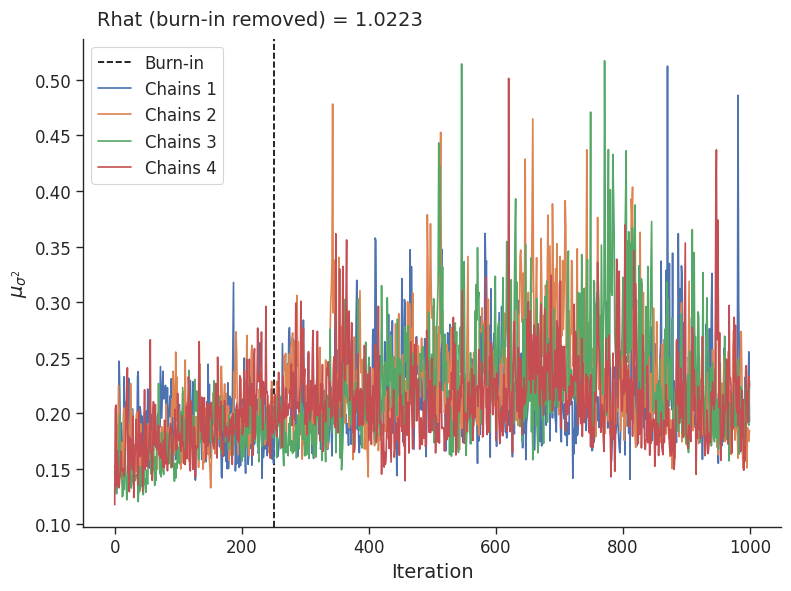

In [105]:
plt.figure(figsize=(8, 6))
plt.axvline(x = burn_in, color = 'black', linestyle='dashed', label = 'Burn-in')
for i in range(posterior_samples_mu_sigmasq.shape[0]): # looping over chains
    plt.plot(posterior_samples_mu_sigmasq[i, :], label=f"Chains {i+1}")
plt.xlabel("Iteration")
plt.ylabel(r"$\mu_{\sigma^2}$")
plt.annotate(r'Rhat (burn-in removed) = {:.4f}'.format(calculate_r_hat(posterior_samples_mu_sigmasq[:,burn_in:])), xy=(0.02, 1.03), size= 14, xycoords='axes fraction')
plt.legend(fontsize=12) 
plt.tight_layout()
plt.show()

#### Posterior distribution of $\beta_{\sigma2}$

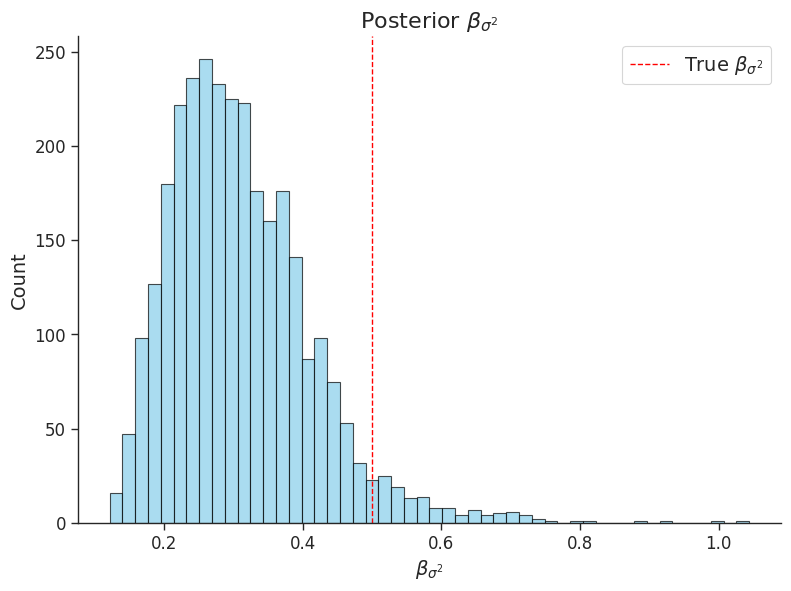

In [106]:
post_beta_sigmasq = posterior_samples_beta_sigmasq[:,burn_in:] # (num_chains, num_iterations)
post_beta_sigmasq = post_beta_sigmasq.reshape(-1) # collapse samples over the chains

plt.figure(figsize=(8, 6))
plt.hist(post_beta_sigmasq, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel(r"$\beta_{\sigma^2}$")
plt.ylabel("Count")
plt.axvline(true_beta_sigmasq, color='red', linestyle='dashed', linewidth=1, label=r'True $\beta_{\sigma^2}$')
plt.legend(fontsize=14)
plt.title(r"Posterior $\beta_{\sigma^2}$")
plt.tight_layout()
plt.show()

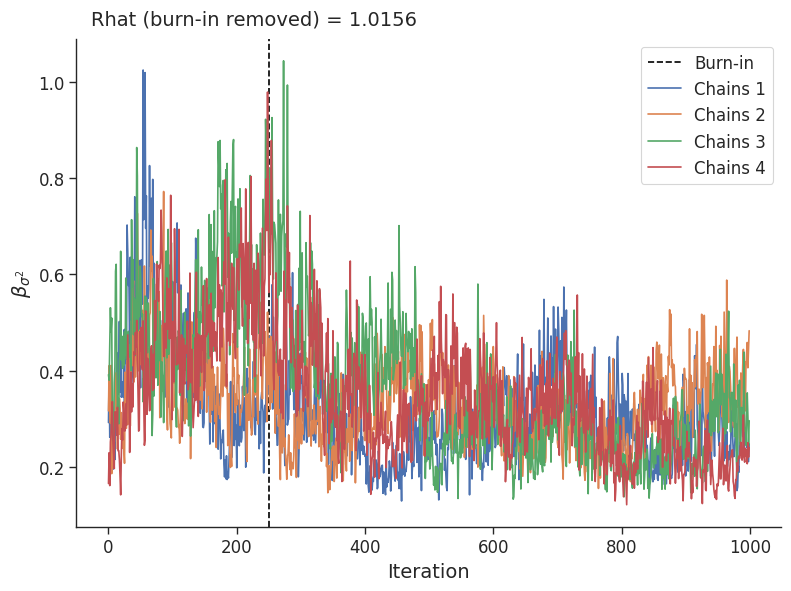

In [107]:
plt.figure(figsize=(8, 6))
plt.axvline(x = burn_in, color = 'black', linestyle='dashed', label = 'Burn-in')
for i in range(posterior_samples_beta_sigmasq.shape[0]): # looping over chains
    plt.plot(posterior_samples_beta_sigmasq[i, :], label=f"Chains {i+1}")
plt.xlabel("Iteration")
plt.ylabel(r"$\beta_{\sigma^2}$")
plt.annotate(r'Rhat (burn-in removed) = {:.4f}'.format(calculate_r_hat(posterior_samples_beta_sigmasq[:,burn_in:])), xy=(0.02, 1.03), size= 14, xycoords='axes fraction')
plt.legend(fontsize=12) 
plt.tight_layout()
plt.show()

#### Posterior distribution of $\sigma_{\mu_x}$

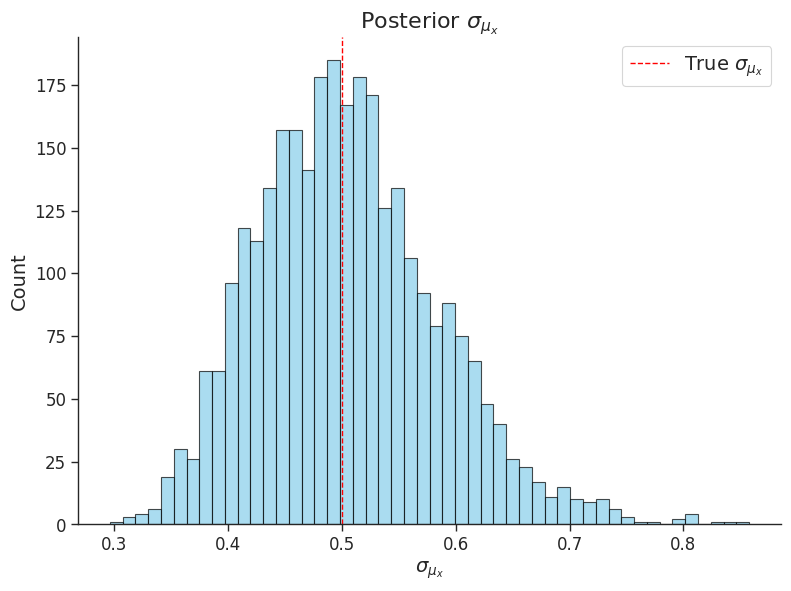

In [108]:
post_sigma_mu_x = posterior_samples_sigma_mu_x[:,burn_in:] # (num_chains, num_iterations)
post_sigma_mu_x = post_sigma_mu_x.reshape(-1) # collapse samples over the chains

plt.figure(figsize=(8, 6))
plt.hist(post_sigma_mu_x, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel(r"$\sigma_{\mu_x}$")
plt.ylabel("Count")
plt.axvline(true_sigma_mu_x, color='red', linestyle='dashed', linewidth=1, label=r'True $\sigma_{\mu_x}$')
plt.legend(fontsize=14)
plt.title(r"Posterior $\sigma_{\mu_x}$")
plt.tight_layout()
plt.show()

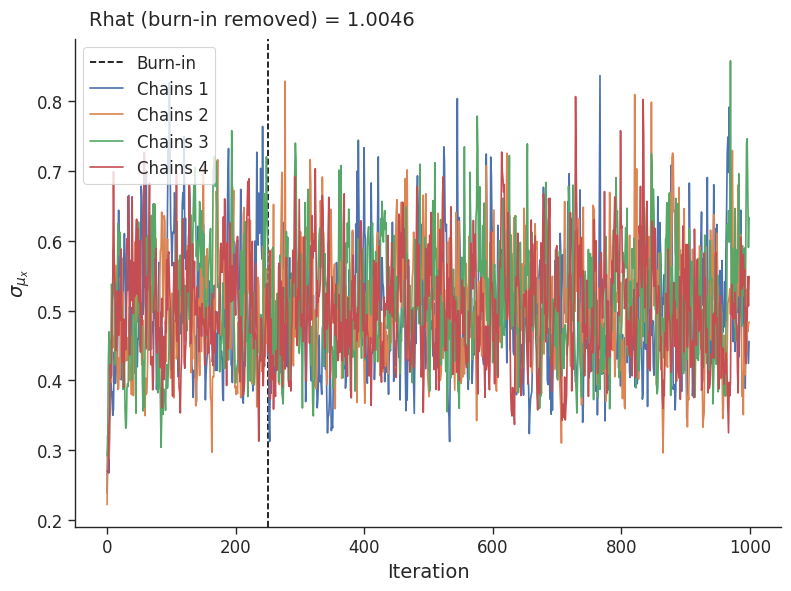

In [109]:
plt.figure(figsize=(8, 6))
plt.axvline(x = burn_in, color = 'black', linestyle='dashed', label = 'Burn-in')
for i in range(posterior_samples_sigma_mu_x.shape[0]): # looping over chains
    plt.plot(posterior_samples_sigma_mu_x[i, :], label=f"Chains {i+1}")
plt.xlabel("Iteration")
plt.ylabel(r"$\sigma_{\mu_x}$")
plt.annotate(r'Rhat (burn-in removed) = {:.4f}'.format(calculate_r_hat(posterior_samples_sigma_mu_x[:,burn_in:])), xy=(0.02, 1.03), size= 14, xycoords='axes fraction')
plt.legend(fontsize=12) 
plt.tight_layout()
plt.show()